<a href="https://colab.research.google.com/github/jjyjung/ai_semicon/blob/main/src/dnn/tf_keras_DNN_iris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from pathlib import Path
from tensorflow.keras.layers import Dense, Input, Dropout  # 모듈(변수나 함수를 포함)만 불러오기

np.random.seed(42)
tf.random.set_seed(42)

In [2]:
# ## PC의 Jupyter Notebook에서 실행할 때 사용하는 코드
# ## Jupyter Notebook에서 실행시킬 때에는 아래 2개 셀 대신에 이 셀을 실행하세요.

# # BMI 데이터를 읽기
# dir = "./"  # 현재 경로에 bmi.csv가 저장되어 있다고 가정함
# df = pd.read_csv(dir + "bmi.csv")    ### [중요!!] https://github.com/jjyjung/ai/blob/gh-pages/bmi.csv 에서 다운받을 수 있습니다.

In [16]:
### Colab에서 Google Drive에 저장된 파일에 접근할 때 필요한 코드
from google.colab import drive
drive.mount('/content/gdrive')   # google drive를 google colab에 연결. 처음 실행 시, 인증 필요

# BMI 데이터를 읽어서 Data Frame으로 저장하기
dir = "/content/gdrive/My Drive/Colab Notebooks/ai_semicon/DNN/"  ### [중요!!] Colab의 경우, bmi.csv를 저장할 위치를 기록하시오.
DATA_PATH = Path(dir + "iris_shuffle.csv")    ### [중요!!] https://github.com/jjyjung/ai/blob/gh-pages/bmi.csv 에서 다운받을 수 있습니다.
DATA_URL = 'https://raw.githubusercontent.com/jjyjung/ai/gh-pages/bmi.csv'

df = pd.read_csv(DATA_PATH if DATA_PATH.exists() else DATA_URL, header=None)
df.head()

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


,0,1,2,3,4
0,7.1,3.0,5.9,2.1,Iris-virginica
1,4.6,3.4,1.4,0.3,Iris-setosa
2,6.3,2.3,4.4,1.3,Iris-versicolor
3,4.8,3.0,1.4,0.1,Iris-setosa
4,6.7,3.3,5.7,2.1,Iris-virginica


In [20]:
# 몸무게와 키 데이터 약식 정규화
# df["weight"] /= 100   # normalization
# df["height"] /= 200   # normalization
# X = df[["weight", "height"]].to_numpy(dtype=np.float32)

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X = scaler.fit_transform(df.iloc[:, :4])

# 레이블링, 라벨링 (labelling) => one-hot encoding
bclass = {"Iris-setosa":[1,0,0], "Iris-versicolor":[0,1,0], "Iris-virginica":[0,0,1]}
y = np.empty((150,3))     # 20000x3 크기의 다차원 벡터 생성
for i, v in enumerate(df[4]):
    y[i] = bclass[v]        # "thin'이면, y[i]=[1,0,0] 와 같이 할당

# 훈련 전용 데이터와 테스트 전용 데이터로 나누기
X_train, y_train = X[0:100], y[0:100]
X_test,  y_test  = X[100:], y[100:]

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((100, 4), (100, 3), (50, 4), (50, 3))

In [21]:
print(type(X_train))
print(type(y_train))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [22]:
X_train

array([[0.77777778, 0.41666667, 0.83050847, 0.83333333],
       [0.08333333, 0.58333333, 0.06779661, 0.08333333],
       [0.55555556, 0.125     , 0.57627119, 0.5       ],
       [0.13888889, 0.41666667, 0.06779661, 0.        ],
       [0.66666667, 0.54166667, 0.79661017, 0.83333333],
       [0.55555556, 0.20833333, 0.6779661 , 0.75      ],
       [0.94444444, 0.33333333, 0.96610169, 0.79166667],
       [0.47222222, 0.41666667, 0.6440678 , 0.70833333],
       [0.55555556, 0.20833333, 0.66101695, 0.58333333],
       [0.25      , 0.875     , 0.08474576, 0.        ],
       [0.72222222, 0.45833333, 0.66101695, 0.58333333],
       [0.22222222, 0.75      , 0.08474576, 0.08333333],
       [0.66666667, 0.45833333, 0.57627119, 0.54166667],
       [0.22222222, 0.625     , 0.06779661, 0.08333333],
       [0.16666667, 0.45833333, 0.08474576, 0.        ],
       [0.41666667, 0.29166667, 0.52542373, 0.375     ],
       [0.80555556, 0.66666667, 0.86440678, 1.        ],
       [0.66666667, 0.45833333,

In [23]:
# 모델 구조 정의하기
model = tf.keras.Sequential([
    Input(shape=(4,)),               # 입력 2개로부터 전달받음
    Dense(8, activation='relu'),     # ReLU 활성화함수 채택
    Dropout(0.1),                    # dropout ratio=10% (훈련시 10% arc 무시)
    Dense(4, activation='relu'),
    Dropout(0.1),
    Dense(3, activation='softmax'),  # 분류을 위해 softmax 함수 사용
])

# 모델 구축하기
model.compile(
    loss='categorical_crossentropy',  # 다중 교차엔트로피
    optimizer=tf.keras.optimizers.RMSprop(),   # 최적화 기법 중 하나 (tf.keras.optimizers.RMSprop(learning_rate=0.1)
    metrics=['accuracy'])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 91 (364.00 B)

 Trainable params: 91 (364.00 B)

 Non-trainable params: 0 (0.00 B)

In [24]:
# 'val_loss'를 monitor하여 감소하면 10회 더 참고 조기중지
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
)

# 데이터 훈련하기
hist = model.fit(
    X_train, y_train,
    batch_size=100,       # 100개에 한 번씩 업데이터 실행
    epochs=500,            # 훈련 데이터셋을 총 60회 반복 실험. 단, 조기중지될 수 있음
    validation_split=0.2, # validation data 분할 비율. 즉, 15000개 중에서 10%인 1500개를 validation용으로 분할
    callbacks=[early_stopping],
    verbose=1)   # 전 과정을 화면에 출력(1) 또는 미출력(0) 모드

# 테스트 데이터로 평가하기
score = model.evaluate(X_test, y_test)
print('test_loss: ', score[0])
print('test_acc: ', score[1])

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.3500 - loss: 1.0898 - val_accuracy: 0.4500 - val_loss: 1.0702
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.3875 - loss: 1.0787 - val_accuracy: 0.4500 - val_loss: 1.0652
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.3500 - loss: 1.0775 - val_accuracy: 0.4500 - val_loss: 1.0622
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.3625 - loss: 1.0649 - val_accuracy: 0.4500 - val_loss: 1.0587
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.3750 - loss: 1.0722 - val_accuracy: 0.4500 - val_loss: 1.0548
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.3500 - loss: 1.0804 - val_accuracy: 0.4500 - val_loss: 1.0522
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.3750 - loss: 1.0678 - val_accuracy: 0.4500 - val_loss: 1.0497
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.3625 - loss: 1.0716 - val_accuracy: 0.4500 - val_loss: 1

In [25]:
score

[0.45278820395469666, 0.7799999713897705]

In [26]:
hist.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

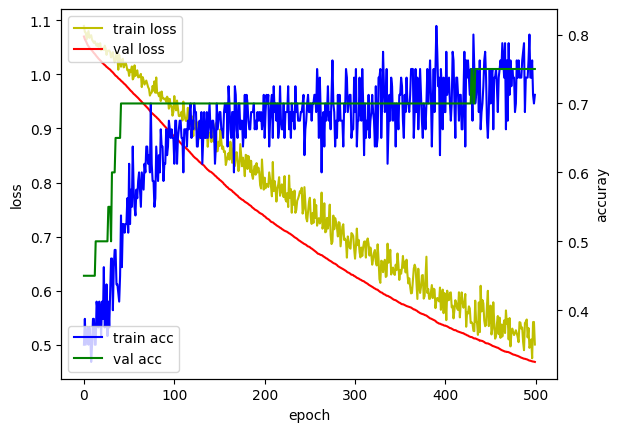

In [27]:
import matplotlib.pyplot as plt

fig, loss_ax = plt.subplots()
acc_ax = loss_ax.twinx()

loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val loss')

acc_ax.plot(hist.history['accuracy'], 'b', label='train acc')
acc_ax.plot(hist.history['val_accuracy'], 'g', label='val acc')

loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuray')

loss_ax.legend(loc='upper left')
acc_ax.legend(loc='lower left')

plt.show()

In [28]:
model.get_weights()

[array([[-0.04725287,  0.41481557, -0.3355877 ,  0.6306273 , -0.7420063 ,
         -0.20914344, -0.2594172 ,  0.23746137],
        [ 0.8236229 , -0.14289491, -0.67913157, -0.06630395,  0.82304734,
         -0.31034485, -0.62382525, -0.22358385],
        [ 0.31437007, -0.33003265, -0.17572266,  0.4493789 ,  0.14662927,
          1.10682   ,  0.16345239,  0.98878115],
        [ 0.7743973 , -0.36519274,  0.00745529,  0.89926296, -0.40139377,
          0.5828155 , -0.39107016,  0.32740003]], dtype=float32),
 array([ 0.11282499, -0.02830113,  0.        , -0.27082375,  0.35497013,
         0.02206163,  0.        , -0.06006819], dtype=float32),
 array([[ 0.94468707,  0.21096016, -0.2626379 ,  0.6992602 ],
        [-0.67000574,  0.37314442, -0.13157642, -0.4456335 ],
        [ 0.21712166, -0.3599162 ,  0.4886462 , -0.58725613],
        [ 0.40667787,  0.74911463,  0.00503417, -0.23658897],
        [-0.6672944 , -0.79475033, -0.6466773 ,  0.37354922],
        [ 1.1650398 ,  0.77918506, -0.280539

In [29]:
from tensorflow.keras.models import load_model

# DNN 모델을 .keras 파일로 저장 (확장자와 경로 정확히 지정)
model.save(dir + "dnn_bmi.keras")
print("Model saved to disk.")

# 저장된 모델 불러오기 (경로와 확장자 정확히 확인)
loaded_model = load_model(dir + "dnn_bmi.keras")
loaded_model.summary()

Model saved to disk.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 184 (740.00 B)

 Trainable params: 91 (364.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 93 (376.00 B)

In [30]:
# 모델을 평가하기
score = model.evaluate(X_test, y_test)
print('test_loss: ', score[0])
print('test_acc: ', score[1])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7800 - loss: 0.4528
test_loss:  0.45278820395469666
test_acc:  0.7799999713897705


In [31]:
# X_test 샘플들의 클래스 예측하기
y_prob = model.predict(X_test)    # X_test의 출력값 확인하기
print(y_prob[:10])

y_class = y_prob.argmax(axis=-1)  # X_test의 클래스 예측하기 (-1은 마지막 축 방향 의미)
y_class[:10]

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
[[1.54427970e-02 4.79098767e-01 5.05458474e-01]
 [5.77853760e-04 2.91610837e-01 7.07811236e-01]
 [6.53260108e-03 4.25699443e-01 5.67767978e-01]
 [7.98694253e-01 1.13510892e-01 8.77949148e-02]
 [6.10890333e-03 4.28598076e-01 5.65293014e-01]
 [7.77823925e-01 1.28400326e-01 9.37758163e-02]
 [7.71547675e-01 1.32940963e-01 9.55113620e-02]
 [5.19223101e-02 5.38665354e-01 4.09412414e-01]
 [2.11968180e-03 3.61913472e-01 6.35966778e-01]
 [8.02049279e-01 1.11148454e-01 8.68022740e-02]]


array([2, 2, 2, 0, 2, 0, 0, 1, 2, 0])

In [32]:
y_prob = model.predict(X_test)  # 예측 확률
y_pred = y_prob.argmax(axis=-1)  # 예측 클래스 번호
y_true = y_test.argmax(axis=-1) # 실제 클래스 번호

# 레이블로 변환 준비
class_name = np.array(["thin", "normal", "fat"])

print("Predicted probabilities:\n", y_prob[0:10])
print("Predicted class:", y_pred[0:10], class_name[y_pred[0:10]])
print("Actual class:", y_true[0:10], class_name[y_true[0:10]])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Predicted probabilities:
 [[1.54427970e-02 4.79098767e-01 5.05458474e-01]
 [5.77853760e-04 2.91610837e-01 7.07811236e-01]
 [6.53260108e-03 4.25699443e-01 5.67767978e-01]
 [7.98694253e-01 1.13510892e-01 8.77949148e-02]
 [6.10890333e-03 4.28598076e-01 5.65293014e-01]
 [7.77823925e-01 1.28400326e-01 9.37758163e-02]
 [7.71547675e-01 1.32940963e-01 9.55113620e-02]
 [5.19223101e-02 5.38665354e-01 4.09412414e-01]
 [2.11968180e-03 3.61913472e-01 6.35966778e-01]
 [8.02049279e-01 1.11148454e-01 8.68022740e-02]]
Predicted class: [2 2 2 0 2 0 0 1 2 0] ['fat' 'fat' 'fat' 'thin' 'fat' 'thin' 'thin' 'normal' 'fat' 'thin']
Actual class: [1 2 1 0 1 0 0 1 2 0] ['normal' 'fat' 'normal' 'thin' 'normal' 'thin' 'thin' 'normal' 'fat'
 'thin']


In [33]:
def normalize_samples(samples):
    samples = np.asarray(samples, dtype=np.float32).copy()
    samples[:, 0] /= 100
    samples[:, 1] /= 200
    return samples


def predict_samples(samples):
    samples = normalize_samples(samples)
    prob = model.predict(samples, verbose=0)
    pred = prob.argmax(axis=-1)
    return samples, prob, pred


# 새로운 샘플의 클래스 예측하기
X_new = [[80, 180]]
normalized_new, y_prob, y_pred = predict_samples(X_new)

print('Normalized input:', normalized_new.tolist())
print('Predicted probabilities:\n', y_prob, class_name[y_pred])
print('Predicted class:', y_pred, class_name[y_true])

InvalidArgumentError: Graph execution error:

Detected at node sequential_1_1/dense_3_1/Relu defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py", line 37, in <module>

  File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 992, in launch_instance

  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelapp.py", line 712, in start

  File "/usr/local/lib/python3.12/dist-packages/tornado/platform/asyncio.py", line 211, in start

  File "/usr/lib/python3.12/asyncio/base_events.py", line 645, in run_forever

  File "/usr/lib/python3.12/asyncio/base_events.py", line 1999, in _run_once

  File "/usr/lib/python3.12/asyncio/events.py", line 88, in _run

  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelbase.py", line 510, in dispatch_queue

  File "/usr/local/lib/python3.12/dist

**자신을 포함한 가족들의 BMI 측정해보기**

In [ ]:
# # 새로운 샘플의 클래스 예측하기
# X_news = np.array([[,], [,], [,], [,]], dtype=float)

# # ~~~
# # ~~~
# # ~~~

# class_name = np.array(["thin", "normal", "fat"])

# # ~~~
# # ~~~
# # ~~~


In [ ]:
# 새로운 샘플의 클래스 예측하기
X_news = np.array([[78,183], [55, 160], [50,170]], dtype=float)
X_news[:,0] /= 100
X_news[:,1] /= 200
print("Normalized input:", X_news)

# 모델을 사용하여 클래스 확률 예측
y_prob = model.predict(X_news) # X_new를 2D 배열로 전달해야 함
y_pred = y_prob.argmax(axis=-1)        # X_new의 클래스 예측하기

print("Predicted probabilities:\n", y_prob)
print("Predicted class:", y_pred)
print("Predicted label:", class_name[y_pred])

In [ ]:
X_news = [[78, 183], [55, 160], [50, 170]]
normalized_news, y_prob, y_pred = predict_samples(X_news)

print('Normalized input:', normalized_news.tolist())
print('Predicted probabilities:\n', y_prob)
print('Predicted class:', y_pred)
print('Predicted label:', class_name[y_pred])